In [ ]:
!pip install transformers sentencepiece openpyxl

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import BertTokenizer, BertModel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Deep Learning/Gene_List_421_421.xlsx' #The same as "balanced labeld dataset in the manuscript"
df = pd.read_excel(file_path)

# Ensure column is named 'Sequence'
df.drop(columns=['Gene ID', 'Transcript ID', 'Length', 'Reference'], inplace=True)
df.rename(columns={'(Pre)protein sequence': 'Sequence'}, inplace=True)
df['Label'] = df['Label'].replace(['CP', 'NotCP'], [1, 0])
df = df[df['Sequence'].notna()]

Mounted at /content/drive


/tmp/ipython-input-1223562938.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Label'] = df['Label'].replace(['CP', 'NotCP'], [1, 0])


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

X_raw = df['Sequence'].values
y_raw = df['Label'].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_train_raw, y_train_raw, test_size=0.25, stratify=y_train_raw, random_state=42)

# Convert to DataFrame
pd.DataFrame(X_train_raw).to_excel('/content/drive/MyDrive/Deep Learning/X_train_250716.xlsx', index=False)
pd.DataFrame(X_val_raw).to_excel('/content/drive/MyDrive/Deep Learning/X_val_250716.xlsx', index=False)
pd.DataFrame(X_test_raw).to_excel('/content/drive/MyDrive/Deep Learning/X_test_250716.xlsx', index=False)

pd.DataFrame(y_train_raw).to_excel('/content/drive/MyDrive/Deep Learning/y_train_250716.xlsx', index=False)
pd.DataFrame(y_val_raw).to_excel('/content/drive/MyDrive/Deep Learning/y_val_250716.xlsx', index=False)
pd.DataFrame(y_test_raw).to_excel('/content/drive/MyDrive/Deep Learning/y_test_250716.xlsx', index=False)

In [ ]:
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert_bfd", do_lower_case=False)
model = BertModel.from_pretrained("Rostlab/prot_bert_bfd")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30, 1024, padding_idx=0)
    (position_embeddings): Embedding(40000, 1024)
    (token_type_embeddings): Embedding(2, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-29): 30 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.0, i

In [ ]:
def preprocess_sequence(seq):
    seq = seq.strip()
    return ' '.join(list(seq))  # space-separated amino acids for ProtBERT-BFD

df['input_seq'] = df['Sequence'].apply(preprocess_sequence)

In [ ]:
MAX_LEN = 1000
EMBED_DIM = model.config.hidden_size  # 1024

def preprocess_sequence(seq):
    return " ".join(list(seq.strip()))

def extract_token_embeddings(sequence):
    try:
        sequence = preprocess_sequence(sequence)
        tokens = tokenizer(sequence,
                           return_tensors='pt',
                           padding='max_length',
                           truncation=True,
                           max_length=MAX_LEN)
        tokens = {key: val.to(device) for key, val in tokens.items()}
        with torch.no_grad():
            output = model(**tokens)
        token_embeddings = output.last_hidden_state.squeeze(0).cpu().numpy()  # shape: (MAX_LEN, 1024)
        return token_embeddings
    except Exception as e:
        print(f"Error with sequence: {e}")
        return np.zeros((MAX_LEN, EMBED_DIM))

In [ ]:
################# ***** Can skip ***** #################

from tqdm import tqdm
import numpy as np

X_train = np.array([extract_token_embeddings(seq) for seq in tqdm(X_train_raw, desc="Embedding train")])
X_val   = np.array([extract_token_embeddings(seq) for seq in tqdm(X_val_raw, desc="Embedding val")])
X_test  = np.array([extract_token_embeddings(seq) for seq in tqdm(X_test_raw, desc="Embedding test")])

# Check the shape after split
print(f"Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}, Test set shape: {X_test.shape}")

Embedding train:   0%|          | 0/504 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Embedding test: 100%|██████████| 169/169 [00:46<00:00,  3.67it/s]


Training set shape: (504, 1000, 1024), Validation set shape: (169, 1000, 1024), Test set shape: (169, 1000, 1024)


In [ ]:
################# ***** Can skip ***** #################

from google.colab import drive
drive.mount('/content/drive')

np.save("/content/drive/MyDrive/Deep Learning/X_train.npy", X_train)
np.save("/content/drive/MyDrive/Deep Learning/X_val.npy", X_val)
np.save("/content/drive/MyDrive/Deep Learning/X_test.npy", X_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
################# ***** Starting ***** #################

from google.colab import drive
drive.mount('/content/drive')

X_train = np.load("/content/drive/MyDrive/Deep Learning/X_train.npy")
X_val   = np.load("/content/drive/MyDrive/Deep Learning/X_val.npy")
X_test  = np.load("/content/drive/MyDrive/Deep Learning/X_test.npy")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Add
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

#Add trainable positional encoding layer
class PositionalEncoding(Layer):
    def __init__(self, maxlen, embed_dim, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.pos_emb = self.add_weight(
            shape=(1, maxlen, embed_dim),
            initializer="random_normal",
            trainable=True,
            name="positional_encoding"
        )

    def call(self, x):
        return x + self.pos_emb

#Attention-based Pooling
class AttentivePooling(Layer):
    def __init__(self, **kwargs):
        super(AttentivePooling, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="attn_weights", shape=(input_shape[-1], 1),
                                 initializer="glorot_uniform", trainable=True)
        super(AttentivePooling, self).build(input_shape)

    def call(self, x, return_attention=False):
        # x: (batch, seq_len, hidden)
        scores = tf.nn.softmax(tf.matmul(x, self.W), axis=1)  # (batch, seq_len, 1)
        context = tf.reduce_sum(x * scores, axis=1)
        if return_attention:
            return context, scores
        return context

# === Transformer Feedforward Block ===
def transformer_ffn(x, hidden_dim=512):
    ff = Dense(hidden_dim, activation='relu')(x)
    ff = Dense(x.shape[-1])(ff)
    x = Add()([x, ff])
    return LayerNormalization()(x)

# Model Parameters
input_dim = X_train.shape[1]  # sequence length (e.g., 1000)
embedding_dim = X_train.shape[2]  # ProtBERT-BFD feature size (1024)
num_classes = 1  # Binary classification (CP vs NotCP)

# Model Architecture
# === Input Layer ===
input_seq = Input(shape=(input_dim, embedding_dim))
pos_enc = PositionalEncoding(input_dim, embedding_dim)(input_seq)

# === BiLSTM Layer ===
normed_input = LayerNormalization()(pos_enc)
bilstm1 = Bidirectional(LSTM(128, return_sequences=True))(normed_input)
bilstm2 = Bidirectional(LSTM(64, return_sequences=True))(bilstm1)
bilstm3 = Bidirectional(LSTM(32, return_sequences=True))(bilstm2)

# === Multi-Head Attention + Residual Connection ===
mha_layer = MultiHeadAttention(num_heads=4, key_dim=64)
attn_output, attn_scores = mha_layer(bilstm3, bilstm3, return_attention_scores=True)
residual = Add()([bilstm3, attn_output])
layno1 = LayerNormalization(epsilon=1e-6)(residual)
layno2 = transformer_ffn(layno1)

# Redefine attentive pooling with return_attention=True
context_vec, attn_pool_weights = AttentivePooling()(layno2, return_attention=True)

# === Global Pooling + Dense Layers ===
#pool = AttentivePooling()(layno2)
drop1 = Dropout(0.45)(context_vec)
dense = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(drop1)
drop2 = Dropout(0.45)(dense)
output = Dense(num_classes, activation='sigmoid')(drop2)

# Compile the Model for training (only using the final output)
training_model = Model(inputs=input_seq, outputs=output)
training_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model architecture
training_model.summary()

# === Inference model that gives output and attention weights ===
inference_model = Model(inputs=input_seq, outputs=[output, attn_scores, attn_pool_weights])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000,      │          0 │ -                 │
│ (InputLayer)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 1000,      │  1,024,000 │ input_layer[0][0] │
│ (PositionalEncodin… │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1000,      │      2,048 │ positional_encod… │
│ (LayerNormalizatio… │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1000, 256) │  1,180,672 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 1000, 128) │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 1000, 64)  │     41,216 │ bidirectional_1[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 1000,     │     66,368 │ bidirectional_2[… │
│ (MultiHeadAttentio… │ 64), (None, 4,    │            │ bidirectional_2[… │
│                     │ 1000, 1000)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1000, 64)  │          0 │ bidirectional_2[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1000, 64)  │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1000, 512) │     33,280 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1000, 64)  │     32,832 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1000, 64)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1000, 64)  │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attentive_pooling   │ [(None, 64),      │         64 │ layer_normalizat… │
│ (AttentivePooling)  │ (None, 1000, 1)]  │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ attentive_poolin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     16,640 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 2,561,985 (9.77 MB)

 Trainable params: 2,561,985 (9.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.5300 - loss: 0.7298
Epoch 1: val_accuracy improved from -inf to 0.69231, saving model to /content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5328 - loss: 0.7276 - val_accuracy: 0.6923 - val_loss: 0.6551 - learning_rate: 1.0000e-04
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.6087 - loss: 0.6561
Epoch 2: val_accuracy improved from 0.69231 to 0.82249, saving model to /content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 812ms/step - accuracy: 0.6123 - loss: 0.6538 - val_accuracy: 0.8225 - val_loss: 0.5503 - learning_rate: 1.0000e-04
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.7304 - loss: 0.5656
Epoch 3: val_accuracy improved from 0.82249 to 0.83432, saving model to /content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 814ms/step - accuracy: 0.7328 - loss: 0.5631 - val_accuracy: 0.8343 - val_loss: 0.4439 - learning_rate: 1.0000e-04
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.8096 - loss: 0.4780
Epoch 4: val_accuracy improved from 0.83432 to 0.84024, saving model to /content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 813ms/step - accuracy: 0.8089 - loss: 0.4786 - val_accuracy: 0.8402 - val_loss: 0.4009 - learning_rate: 1.0000e-04
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.8073 - loss: 0.4565
Epoch 5: val_accuracy improved from 0.84024 to 0.84615, saving model to /content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 865ms/step - accuracy: 0.8115 - loss: 0.4515 - val_accuracy: 0.8462 - val_loss: 0.3553 - learning_rate: 1.0000e-04
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.8544 - loss: 0.3810
Epoch 6: val_accuracy improved from 0.84615 to 0.85207, saving model to /content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 811ms/step - accuracy: 0.8554 - loss: 0.3791 - val_accuracy: 0.8521 - val_loss: 0.3446 - learning_rate: 1.0000e-04
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.8697 - loss: 0.3095
Epoch 7: val_accuracy did not improve from 0.85207
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 773ms/step - accuracy: 0.8696 - loss: 0.3110 - val_accuracy: 0.8521 - val_loss: 0.3353 - learning_rate: 1.0000e-04
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.9153 - loss: 0.2909
Epoch 8: val_accuracy did not improve from 0.85207
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 773ms/step - accuracy: 0.9146 - loss: 0.2913 - val_accuracy: 0.8462 - val_loss: 0.3129 - learning_rate: 1.0000e-04
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.9255 - loss: 0.2309
Epoch 9: val_accuracy did not improve from 0.85207
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 769ms/step - accuracy: 0.9250 - loss: 0.2329 - val_accuracy: 0.8462 - val_loss: 0.3498 - learning_rate: 1.0000e-04
Epoch 10/15
8/8 ━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 987ms/step - accuracy: 0.9253 - loss: 0.2439 - val_accuracy: 0.8698 - val_loss: 0.3316 - learning_rate: 1.0000e-04
Epoch 11/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.9424 - loss: 0.1887
Epoch 11: val_accuracy improved from 0.86982 to 0.87574, saving model to /content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5



Epoch 11: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 795ms/step - accuracy: 0.9426 - loss: 0.1889 - val_accuracy: 0.8757 - val_loss: 0.3236 - learning_rate: 1.0000e-04
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 8.


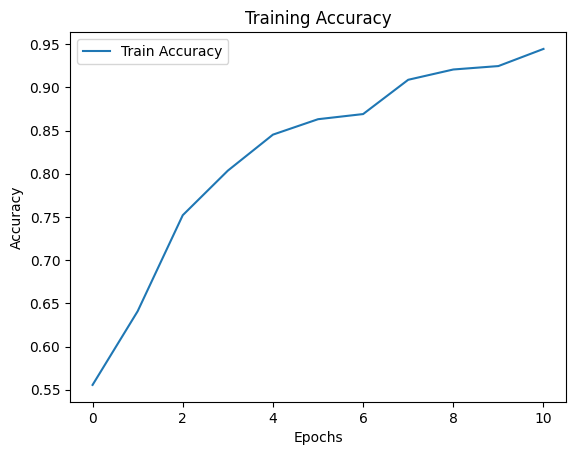

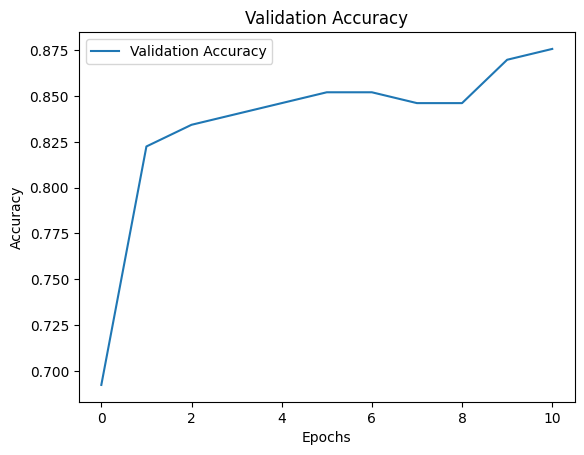

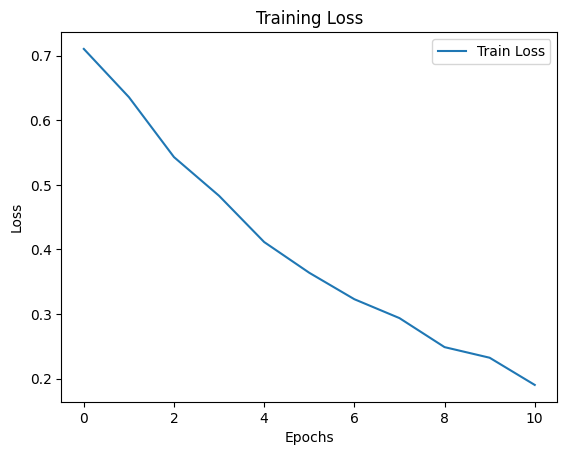

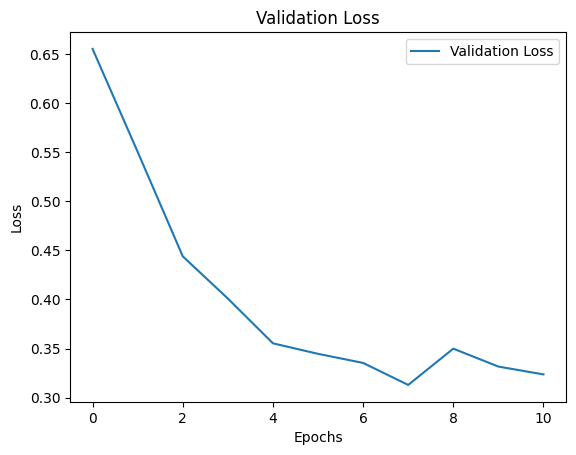

[0.5555555820465088, 0.6408730149269104, 0.7519841194152832, 0.8035714030265808, 0.8452380895614624, 0.863095223903656, 0.8690476417541504, 0.908730149269104, 0.920634925365448, 0.9246031641960144, 0.9444444179534912]
[0.692307710647583, 0.8224852085113525, 0.834319531917572, 0.8402366638183594, 0.8461538553237915, 0.8520709872245789, 0.8520709872245789, 0.8461538553237915, 0.8461538553237915, 0.8698225021362305, 0.8757396340370178]
[0.710500955581665, 0.6358515620231628, 0.543016254901886, 0.4830861985683441, 0.41152963042259216, 0.36395540833473206, 0.3230287432670593, 0.29378995299339294, 0.24887621402740479, 0.2324475198984146, 0.19035905599594116]
[0.655058741569519, 0.550256073474884, 0.4438718855381012, 0.40088891983032227, 0.3552775979042053, 0.344570130109787, 0.33530616760253906, 0.3129132390022278, 0.34984683990478516, 0.3315872848033905, 0.32363343238830566]


In [ ]:
################# ***** Can skip ***** #################

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Callbacks for early stopping and model checkpointing
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
mc = ModelCheckpoint('/content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Train the model
history = training_model.fit(X_train, y_train_raw, validation_data=(X_val, y_val_raw), epochs=15, batch_size=64, callbacks=[mc, es, rlr])

# Visualize training and validation accuracy/loss curves
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.show()

# x-axis: Epochs (0-based index)
epochs = list(range(len(history.history['loss'])))

# y-axis data
train_acc = history.history['accuracy']
print(train_acc)
val_acc = history.history['val_accuracy']
print(val_acc)
train_loss = history.history['loss']
print(train_loss)
val_loss = history.history['val_loss']
print(val_loss)

In [ ]:
# Evaluate the model on the test set
from tensorflow.keras.models import load_model
from google.colab import drive
drive.mount('/content/drive')
# Load the best model: Previous best - /content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5
training_model = load_model(
    "/content/drive/MyDrive/Deep Learning/Clean_up_best_final_model_250805.h5",
    custom_objects={
        'PositionalEncoding': PositionalEncoding,
        'AttentivePooling': AttentivePooling
    }
)
test_loss, test_accuracy = training_model.evaluate(X_test, y_test_raw)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.8124 - loss: 0.4472
Test Loss: 0.4052, Test Accuracy: 0.8462


In [ ]:
# Make predictions on the test set
y_pred = training_model.predict(X_test)

# Convert predictions to binary (0 or 1)
y_pred_binary = (y_pred > 0.5).astype(int)

# Example: Display confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test_raw, y_pred_binary))

print("Classification Report:")
print(classification_report(y_test_raw, y_pred_binary))

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step
Confusion Matrix:
[[75 10]
 [16 68]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        85
           1       0.87      0.81      0.84        84

    accuracy                           0.85       169
   macro avg       0.85      0.85      0.85       169
weighted avg       0.85      0.85      0.85       169



In [ ]:
from tensorflow.keras.metrics import AUC

training_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

In [ ]:
# Get predicted probabilities
y_pred_prob = training_model.predict(X_test)

# Flatten if needed
y_pred_prob = y_pred_prob.ravel()

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 275ms/step


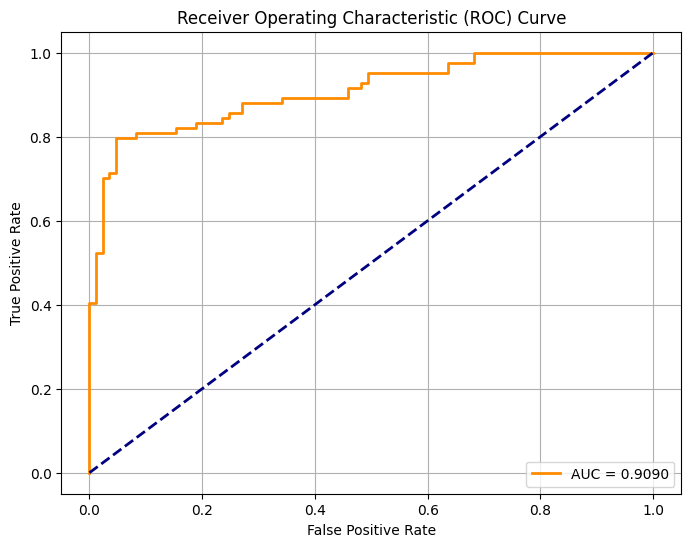

[0.         0.         0.         0.01176471 0.01176471 0.02352941
 0.02352941 0.03529412 0.03529412 0.04705882 0.04705882 0.08235294
 0.08235294 0.15294118 0.15294118 0.18823529 0.18823529 0.23529412
 0.23529412 0.24705882 0.24705882 0.27058824 0.27058824 0.34117647
 0.34117647 0.45882353 0.45882353 0.48235294 0.48235294 0.49411765
 0.49411765 0.63529412 0.63529412 0.68235294 0.68235294 1.        ]
[0.         0.01190476 0.4047619  0.4047619  0.52380952 0.52380952
 0.70238095 0.70238095 0.71428571 0.71428571 0.79761905 0.79761905
 0.80952381 0.80952381 0.82142857 0.82142857 0.83333333 0.83333333
 0.8452381  0.8452381  0.85714286 0.85714286 0.88095238 0.88095238
 0.89285714 0.89285714 0.91666667 0.91666667 0.92857143 0.92857143
 0.95238095 0.95238095 0.97619048 0.97619048 1.         1.        ]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_raw, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

print(fpr)
print(tpr)

In [ ]:
from sklearn.metrics import roc_auc_score

print("AUC score:", roc_auc_score(y_test_raw, y_pred_prob)) # 0.5 = random guessing / 1.0 = perfect classifier / < 0.5 = worse than random (inverted predictions)

AUC score: 0.9089635854341737


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step


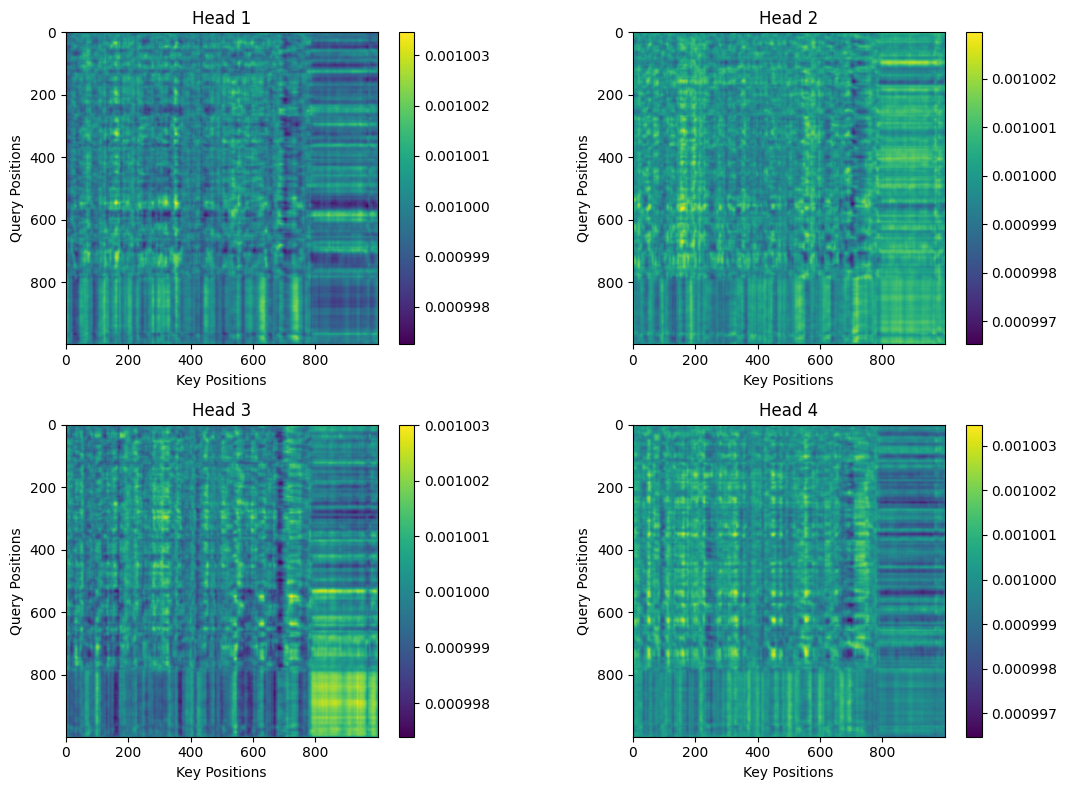

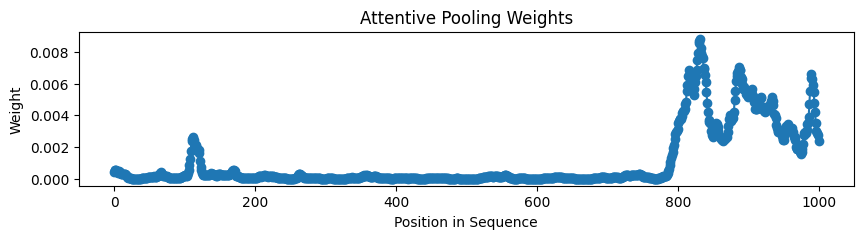

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predict
sample_input = X_test[0:1]  # shape: (1, seq_len, embed_dim)
pred, mha_weights, pool_weights = inference_model.predict(sample_input)

# Plot Multi-Head Attention with colorbars
plt.figure(figsize=(12, 8))
num_heads = mha_weights.shape[1]
rows = (num_heads + 1) // 2

for head in range(num_heads):
    ax = plt.subplot(rows, 2, head + 1)
    im = ax.imshow(mha_weights[0, head], cmap='viridis')
    ax.set_title(f"Head {head+1}")
    ax.set_xlabel("Key Positions")
    ax.set_ylabel("Query Positions")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Add colorbar for each subplot

plt.tight_layout()
plt.show()

# Plot Attentive Pooling Weights
plt.figure(figsize=(10, 2))
plt.plot(pool_weights[0], marker='o')
plt.title("Attentive Pooling Weights")
plt.xlabel("Position in Sequence")
plt.ylabel("Weight")
plt.show()

In [ ]:
#From AttentivePooling Scores (Recommended for overview)
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Get attention weights from all test samples ===
all_pool_weights = []

for i in range(len(X_test)):
    _, _, pool_weights = inference_model.predict(X_test[i:i+1], verbose=0)  # shape: (1, seq_len, 1)
    all_pool_weights.append(pool_weights[0].squeeze())  # shape: (seq_len,)

all_pool_weights = np.array(all_pool_weights)  # shape: (num_samples, seq_len)

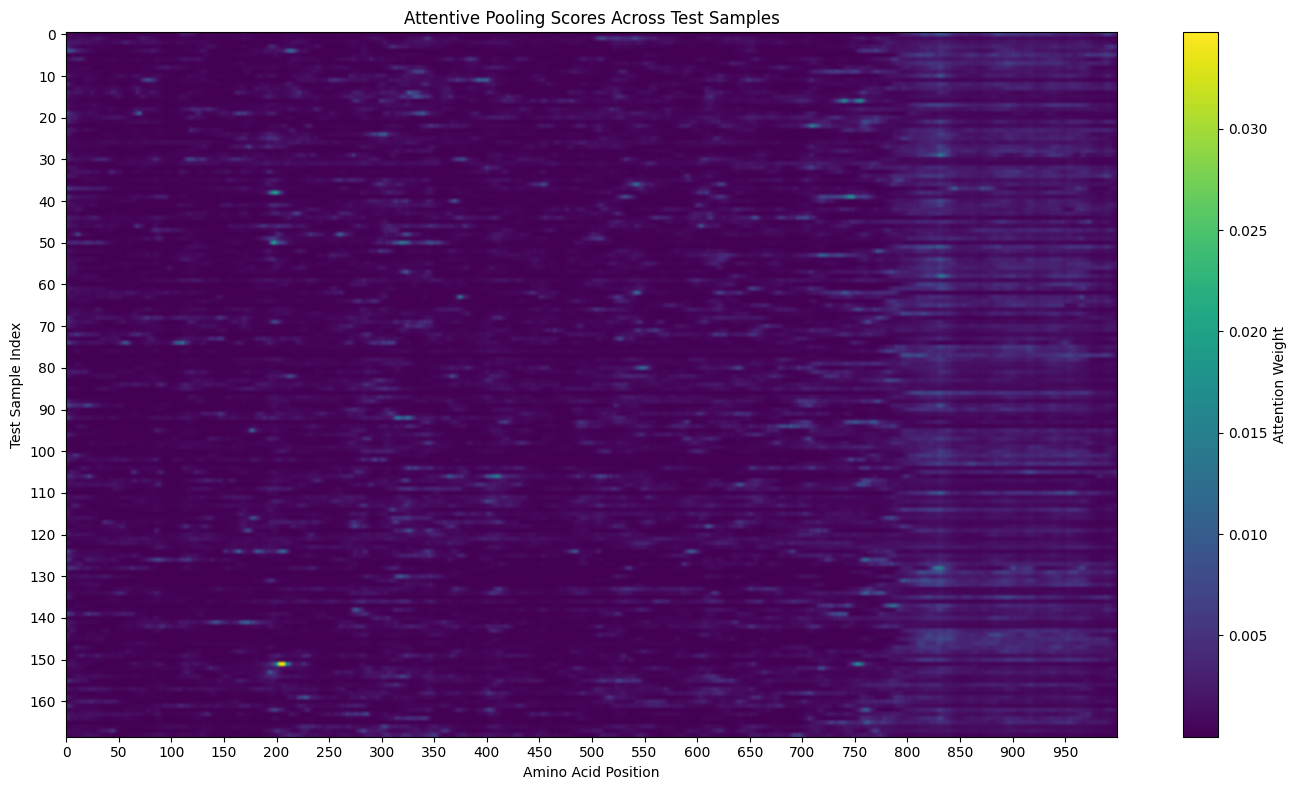

In [ ]:
plt.figure(figsize=(14, 8))
plt.imshow(all_pool_weights, aspect='auto', cmap='viridis')
plt.colorbar(label='Attention Weight')

plt.title("Attentive Pooling Scores Across Test Samples")
plt.xlabel("Amino Acid Position")
plt.ylabel("Test Sample Index")
plt.xticks(np.arange(0, all_pool_weights.shape[1], 50))  # e.g., every 50 positions
plt.yticks(np.arange(0, all_pool_weights.shape[0], 10))  # e.g., every 10 samples
plt.tight_layout()
plt.show()

In [ ]:
#From Multi-Head Attention (Averaged)
all_mha_avg = []

for i in range(len(X_test)):
    _, mha_weights, _ = inference_model.predict(X_test[i:i+1], verbose=0)  # shape: (1, heads, seq_len, seq_len)
    mha_avg = np.mean(mha_weights[0], axis=0)  # average over heads: (seq_len, seq_len)
    token_score = np.mean(mha_avg, axis=0)     # average attention received per token
    all_mha_avg.append(token_score)

all_mha_avg = np.array(all_mha_avg)  # shape: (num_samples, seq_len)

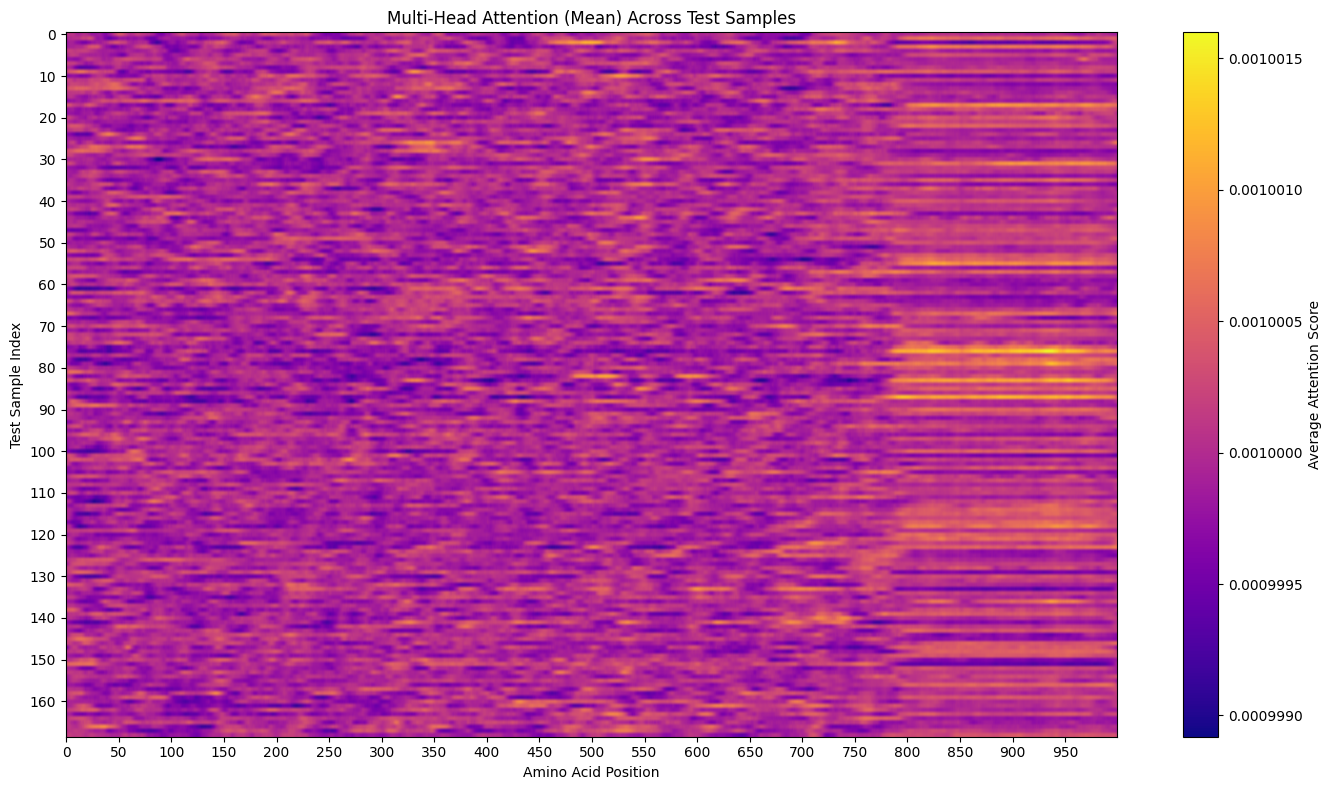

In [ ]:
plt.figure(figsize=(14, 8))
plt.imshow(all_mha_avg, aspect='auto', cmap='plasma')
plt.colorbar(label='Average Attention Score')

plt.title("Multi-Head Attention (Mean) Across Test Samples")
plt.xlabel("Amino Acid Position")
plt.ylabel("Test Sample Index")
plt.xticks(np.arange(0, all_mha_avg.shape[1], 50))
plt.yticks(np.arange(0, all_mha_avg.shape[0], 10))
plt.tight_layout()
plt.show()

#Interpretation
#Bright columns = amino acid positions commonly attended to across samples.
#Bright rows = specific samples with focused attention on certain residues.
#This can help reveal position-specific relevance and sample-specific sensitivity.

In [ ]:
X_test.shape = (169, 1000, 1024)
y_test_raw.shape = (169,)  # Labels: 0 for NotCP, 1 for CP

In [ ]:
#1. Collect all attention scores
from sklearn.preprocessing import MinMaxScaler

all_pool_weights = []

for i in range(len(X_test)):
    _, _, pool_weights = inference_model.predict(X_test[i:i+1], verbose=0)
    all_pool_weights.append(pool_weights[0].squeeze())

all_pool_weights = np.array(all_pool_weights)  # shape: (169, 1000)

In [ ]:
#2. Row-wise normalization (Min-Max per sample)
scaler = MinMaxScaler()

# Normalize each row separately
all_pool_weights_normalized = scaler.fit_transform(all_pool_weights.T).T  # row-wise

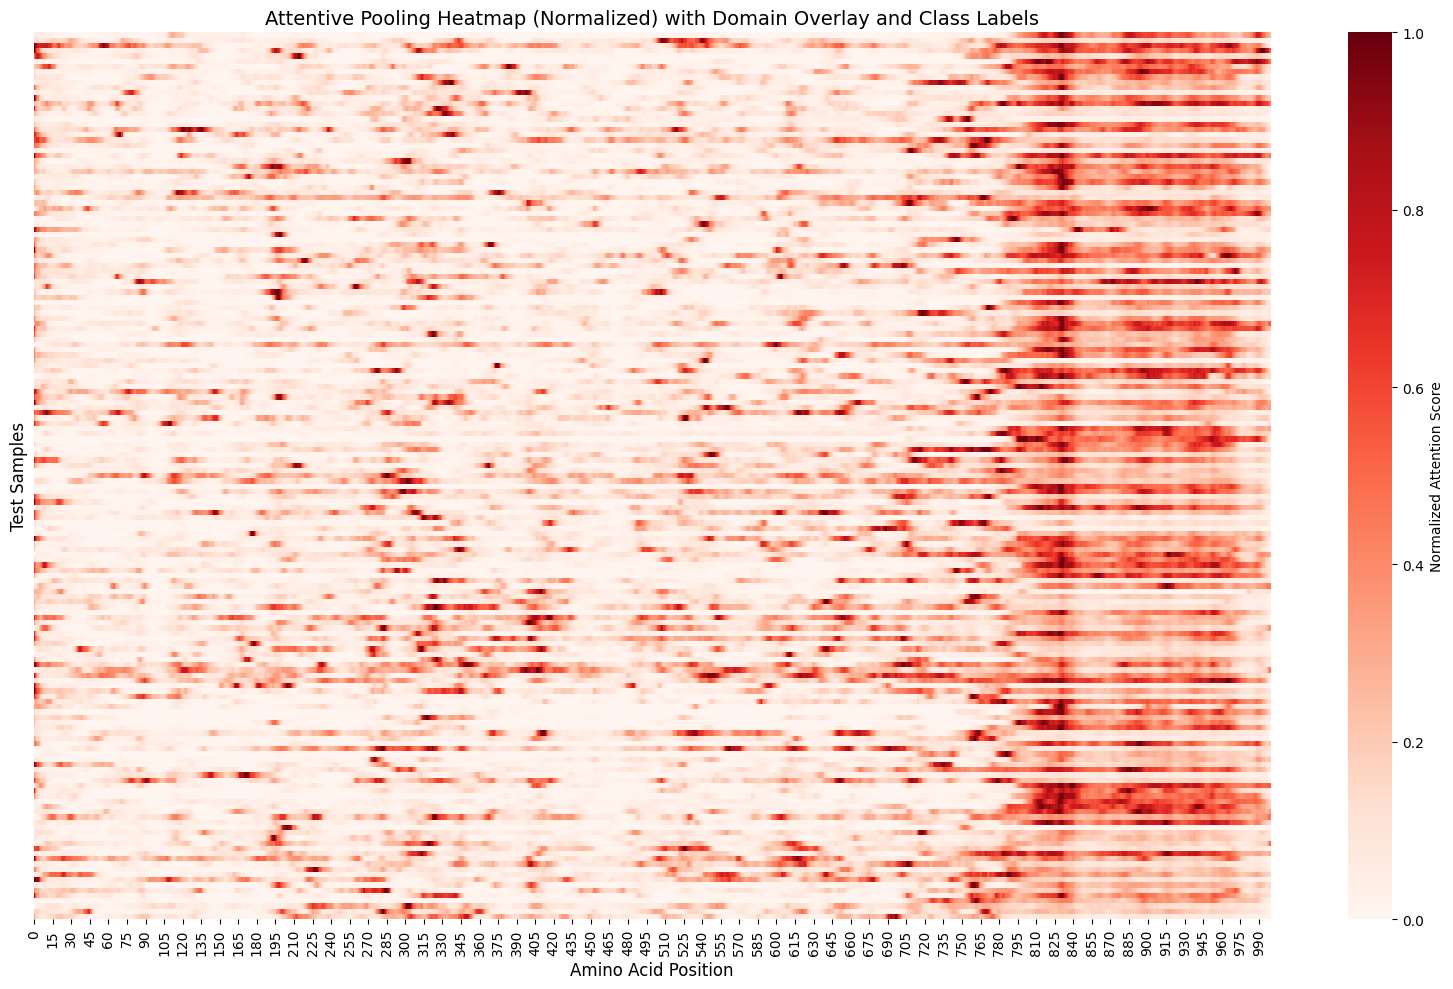

In [ ]:
#3. Plot heatmap with enhancements
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Setup ===
#motif_positions = [50, 100, 150]  # example domain/motif positions
sample_labels = ['CP' if label == 1 else 'NotCP' for label in y_test_raw]

## Create label colors (green for CP, red for NotCP)
#row_colors = ['green' if y == 1 else 'red' for y in y_test_raw]

# === Heatmap ===
plt.figure(figsize=(16, 10))
ax = sns.heatmap(all_pool_weights_normalized, cmap='Reds', cbar_kws={'label': 'Normalized Attention Score'},
                 yticklabels=False)

## Vertical lines for domain/motif positions
#for pos in motif_positions:
#    ax.axvline(x=pos, color='white', linestyle='--', linewidth=1.5, alpha=0.7)

## Add color bar for labels
#for i, color in enumerate(row_colors):
#    ax.add_patch(plt.Rectangle((-0.5, i), 1, 1, fill=False, edgecolor=color, lw=2))

plt.title("Attentive Pooling Heatmap (Normalized) with Domain Overlay and Class Labels", fontsize=14)
plt.xlabel("Amino Acid Position", fontsize=12)
plt.ylabel("Test Samples", fontsize=12)
plt.tight_layout()
plt.show()

#Explanation
#MinMaxScaler: Ensures attention scores are scaled [0,1] per sequence for fair comparison
#ax.axvline(...): Draws vertical white dashed lines at known motif/domain positions
#plt.Rectangle(...): Adds color-coded borders: red = NotCP, green = CP
#sns.heatmap(...): Provides better annotation/grid aesthetics than plt.imshow

#Can I split the plot with the CP group and NotCP (Non-CP) group?

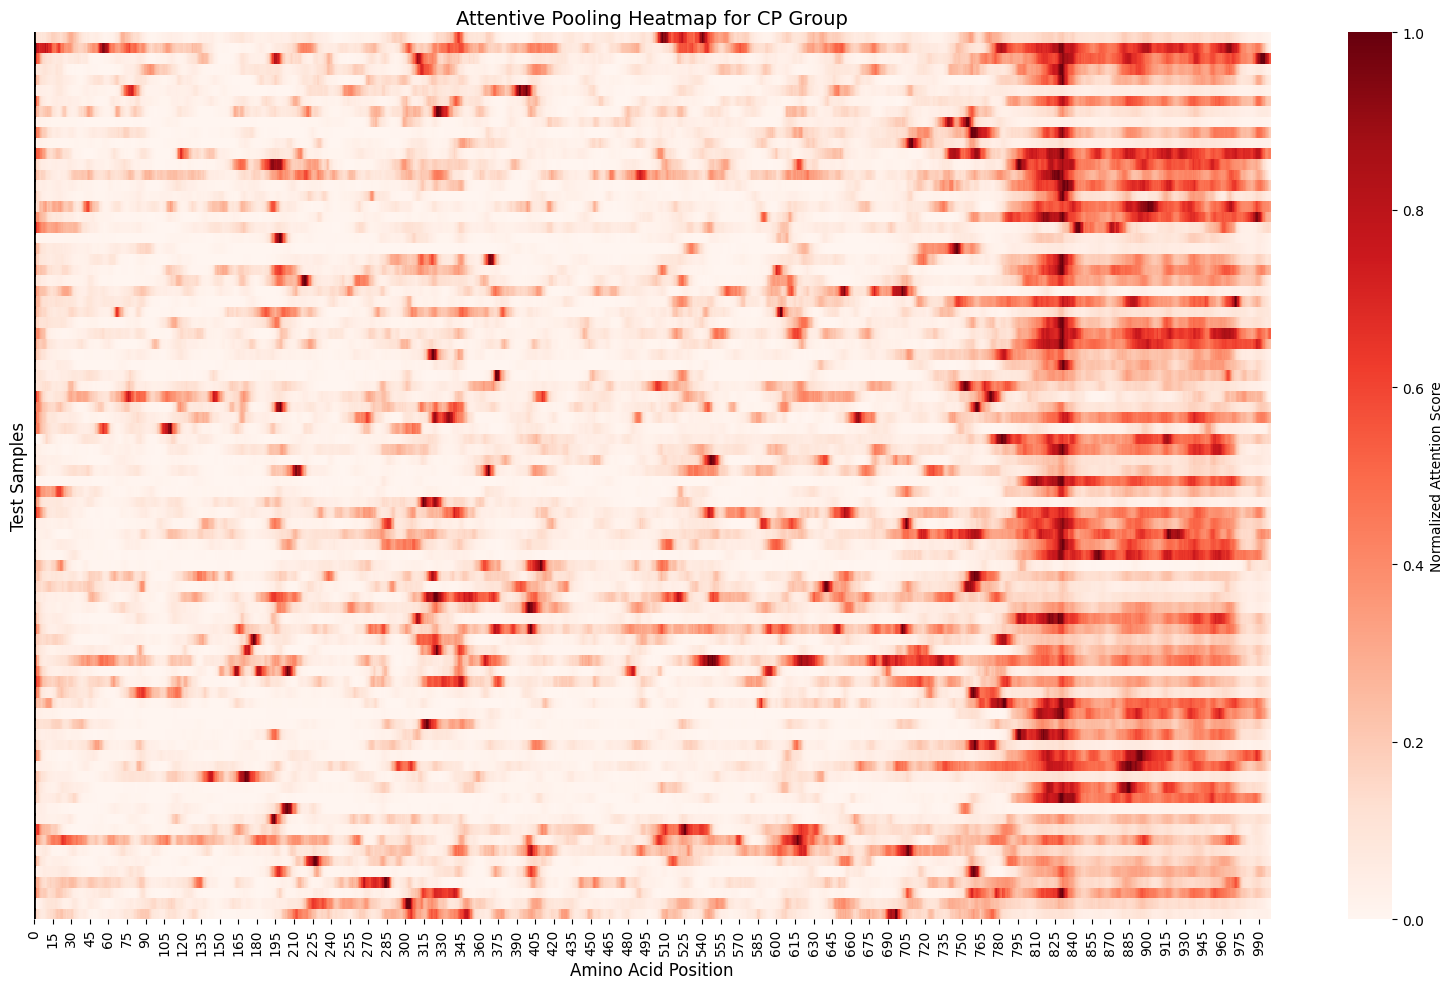

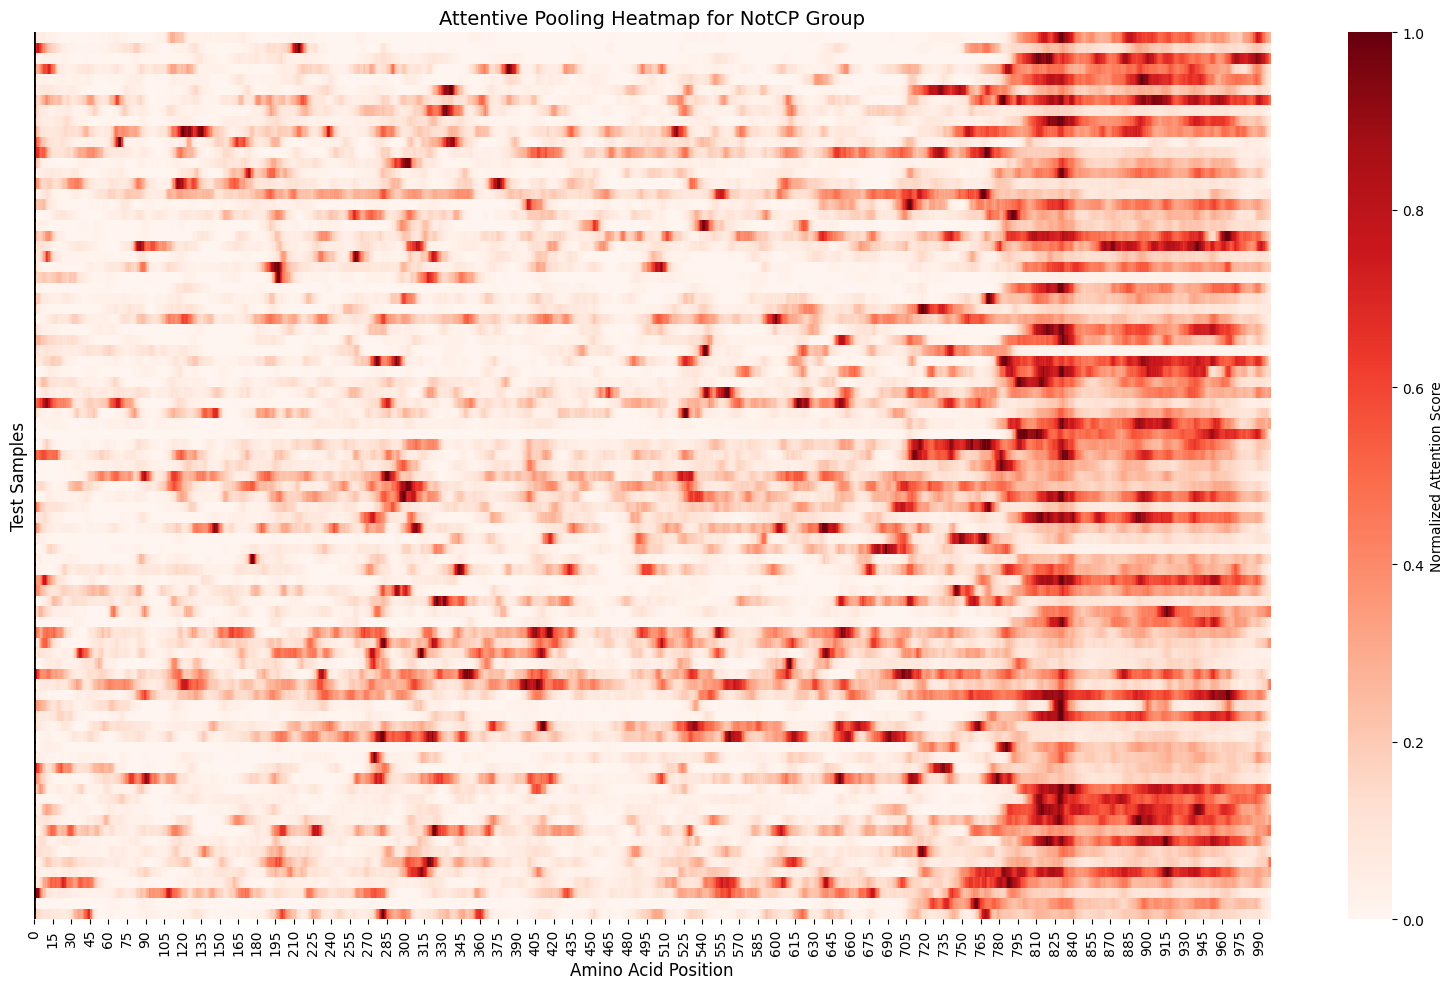

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# === Parameters ===
#motif_positions = [50, 100, 150]  # example motif/domain positions
labels = np.array(y_test_raw)  # Ensure it's a NumPy array

# === 1. Extract attention weights ===
all_pool_weights = []

for i in range(len(X_test)):
    _, _, pool_weights = inference_model.predict(X_test[i:i+1], verbose=0)
    all_pool_weights.append(pool_weights[0].squeeze())  # shape: (1000,)

all_pool_weights = np.array(all_pool_weights)  # shape: (169, 1000)

# === 2. Split CP and NotCP groups ===
cp_indices = np.where(labels == 1)[0]
notcp_indices = np.where(labels == 0)[0]

cp_weights = all_pool_weights[cp_indices]
notcp_weights = all_pool_weights[notcp_indices]

# === 3. Normalize attention weights row-wise (MinMaxScaler) ===
def row_wise_minmax(data):
    scaler = MinMaxScaler()
    return scaler.fit_transform(data.T).T  # Normalize each row independently

cp_weights_norm = row_wise_minmax(cp_weights)
notcp_weights_norm = row_wise_minmax(notcp_weights)

# === 4. Plotting function ===
def plot_attention_heatmap(weights, title):  #raw color, motif_positions
    plt.figure(figsize=(16, 10))
    ax = sns.heatmap(weights, cmap='Reds', cbar_kws={'label': 'Normalized Attention Score'},
                     yticklabels=False)

#    # Vertical lines for motif/domain positions
#    for pos in motif_positions:
#        ax.axvline(x=pos, color='white', linestyle='--', linewidth=1.5, alpha=0.7)

    # Row border color (green for CP, red for NotCP)
    for i in range(weights.shape[0]):
        ax.add_patch(plt.Rectangle((-0.5, i), 1, 1, fill=False, lw=2)) #edgecolor=row_color

    plt.title(title, fontsize=14)
    plt.xlabel("Amino Acid Position", fontsize=12)
    plt.ylabel("Test Samples", fontsize=12)
    plt.tight_layout()
    plt.show()

# === 5. Generate Heatmaps ===
plot_attention_heatmap(cp_weights_norm,
                       title="Attentive Pooling Heatmap for CP Group",
                       ) #row_color='green', motif_positions=motif_positions

plot_attention_heatmap(notcp_weights_norm,
                       title="Attentive Pooling Heatmap for NotCP Group",
                       ) #row_color='red', motif_positions=motif_positions

In [ ]:
# Get Predictions from the Model
# Predict probabilities (float between 0 and 1)
y_train_pred_prob = training_model.predict(X_train)
y_val_pred_prob = training_model.predict(X_val)
y_test_pred_prob = training_model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step


In [ ]:
# Convert Probabilities to Binary Labels
# Convert to 0 (NotCP) or 1 (CP) using threshold 0.5
y_train_pred = (y_train_pred_prob >= 0.5).astype(int).ravel()
y_val_pred = (y_val_pred_prob >= 0.5).astype(int).ravel()
y_test_pred = (y_test_pred_prob >= 0.5).astype(int).ravel()

In [ ]:
train_df = pd.DataFrame({
    'True_Label': y_train_raw,
    'Predicted_Label': y_train_pred
})

val_df = pd.DataFrame({
    'True_Label': y_val_raw,
    'Predicted_Label': y_val_pred
})

test_df = pd.DataFrame({
    'True_Label': y_test_raw,
    'Predicted_Label': y_test_pred
})

In [ ]:
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)

# Save Excel files to that directory
train_df.to_excel(os.path.join(save_dir, "Train_predictions_0805.xlsx"), index=False)
val_df.to_excel(os.path.join(save_dir, "Val_predictions_0805.xlsx"), index=False)
test_df.to_excel(os.path.join(save_dir, "Test_predictions_0805.xlsx"), index=False)

print(f"Files saved to: {save_dir}")

Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
import pandas as pd

# Assume sequences are in a column named 'Sequence'
data_1 = pd.read_excel("/content/drive/MyDrive/Deep Learning/1_A_Excluded_420_Gene_List.xlsx")
sequences_1 = data_1['Sequence'].tolist()

data_3 = pd.read_excel("/content/drive/MyDrive/Deep Learning/3_C_Arabidopsis_Protein_Sequences_1,263.xlsx")
sequences_3 = data_3['Sequence'].tolist()

In [ ]:
################# ***** Can skip ***** #################

# Extract embeddings for each sequence
X_input_1 = np.array([extract_token_embeddings(seq) for seq in tqdm(sequences_1)])  # shape: (N, max_len, 1024)
X_input_3 = np.array([extract_token_embeddings(seq) for seq in tqdm(sequences_3)])  # shape: (N, max_len, 1024)

  0%|          | 0/420 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 1263/1263 [05:43<00:00,  3.67it/s]


In [ ]:
################# ***** Can skip ***** #################

from google.colab import drive
drive.mount('/content/drive')

np.save("/content/drive/MyDrive/Deep Learning/X_input_1.npy", X_input_1)
np.save("/content/drive/MyDrive/Deep Learning/X_input_3.npy", X_input_3)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

X_input_1 = np.load("/content/drive/MyDrive/Deep Learning/X_input_1.npy")
X_input_3 = np.load("/content/drive/MyDrive/Deep Learning/X_input_3.npy")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
y_pred_1 = training_model.predict(X_input_1)
y_pred_3 = training_model.predict(X_input_3)

# Flatten if needed
y_pred_1 = y_pred_1.ravel()
y_pred_3 = y_pred_3.ravel()

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step


In [ ]:
labels_1 = (y_pred_1 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_1['Predicted_Label'] = labels_1
data_1['Probability'] = y_pred_1

labels_3 = (y_pred_3 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_3['Predicted_Label'] = labels_3
data_3['Probability'] = y_pred_3

In [ ]:
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)

# Save Excel files to that directory
data_1.to_excel(os.path.join(save_dir, "Predicted_localization_420_excluded_250805.xlsx"), index=False)
data_3.to_excel(os.path.join(save_dir, "Predicted_localization_Arabidopsis_CP_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

################# ***** Done with small datasets ***** #################

Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
################# ***** (1), (6), (11), (16) ***** #################
import pandas as pd
# Assume sequences are in a column named 'Sequence'
data_2_16 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_P.xlsx")
sequences_2_16 = data_2_16['Sequence'].tolist()
X_input_2_16 = np.array([extract_token_embeddings(seq) for seq in tqdm(sequences_2_16)])  # shape: (N, max_len, 1024)
from google.colab import drive
drive.mount('/content/drive')
np.save("/content/drive/MyDrive/Deep Learning/X_input_2_16.npy",X_input_2_16)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 1000/1000 [04:25<00:00,  3.76it/s]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
################# ***** (1), (6), (11), (16) ***** #################
from google.colab import drive
drive.mount('/content/drive')
data_2_16 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_P.xlsx")
X_input_2_16 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_16.npy")
y_pred_2_16 = training_model.predict(X_input_2_16)
# Flatten if needed
y_pred_2_16 = y_pred_2_16.ravel()
labels_2_16 = (y_pred_2_16 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_16['Predicted_Label'] = labels_2_16
data_2_16['Probability'] = y_pred_2_16
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_16.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(P)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
################# ***** (2), (7), (12), (17) ***** #################
import pandas as pd
# Assume sequences are in a column named 'Sequence'
data_2_17 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_Q.xlsx")
sequences_2_17 = data_2_17['Sequence'].tolist()
X_input_2_17 = np.array([extract_token_embeddings(seq) for seq in tqdm(sequences_2_17)])  # shape: (N, max_len, 1024)
from google.colab import drive
drive.mount('/content/drive')
np.save("/content/drive/MyDrive/Deep Learning/X_input_2_17.npy",X_input_2_17)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 1000/1000 [04:29<00:00,  3.71it/s]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
################# ***** (2), (7), (12), (17) ***** #################
from google.colab import drive
drive.mount('/content/drive')
data_2_17 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_Q.xlsx")
X_input_2_17 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_17.npy")
y_pred_2_17 = training_model.predict(X_input_2_17)
# Flatten if needed
y_pred_2_17 = y_pred_2_17.ravel()
labels_2_17 = (y_pred_2_17 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_17['Predicted_Label'] = labels_2_17
data_2_17['Probability'] = y_pred_2_17
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_17.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(Q)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
################# ***** (3), (8), (13), (18) ***** #################
import pandas as pd
# Assume sequences are in a column named 'Sequence'
data_2_18 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_R.xlsx")
sequences_2_18 = data_2_18['Sequence'].tolist()
X_input_2_18 = np.array([extract_token_embeddings(seq) for seq in tqdm(sequences_2_18)])  # shape: (N, max_len, 1024)
from google.colab import drive
drive.mount('/content/drive')
np.save("/content/drive/MyDrive/Deep Learning/X_input_2_18.npy",X_input_2_18)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 1000/1000 [04:29<00:00,  3.71it/s]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
################# ***** (3), (8), (13), (18) ***** #################
from google.colab import drive
drive.mount('/content/drive')
data_2_18 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_R.xlsx")
X_input_2_18 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_18.npy")
y_pred_2_18 = training_model.predict(X_input_2_18)
# Flatten if needed
y_pred_2_18 = y_pred_2_18.ravel()
labels_2_18 = (y_pred_2_18 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_18['Predicted_Label'] = labels_2_18
data_2_18['Probability'] = y_pred_2_18
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_18.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(R)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
################# ***** (4), (9), (14), (19) ***** #################
import pandas as pd
# Assume sequences are in a column named 'Sequence'
data_2_19 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_S.xlsx")
sequences_2_19 = data_2_19['Sequence'].tolist()
X_input_2_19 = np.array([extract_token_embeddings(seq) for seq in tqdm(sequences_2_19)])  # shape: (N, max_len, 1024)
from google.colab import drive
drive.mount('/content/drive')
np.save("/content/drive/MyDrive/Deep Learning/X_input_2_19.npy",X_input_2_19)

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 1000/1000 [04:28<00:00,  3.73it/s]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
################# ***** (4), (9), (14), (19) ***** #################
from google.colab import drive
drive.mount('/content/drive')
data_2_19 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_S.xlsx")
X_input_2_19 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_19.npy")
y_pred_2_19 = training_model.predict(X_input_2_19)
# Flatten if needed
y_pred_2_19 = y_pred_2_19.ravel()
labels_2_19 = (y_pred_2_19 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_19['Predicted_Label'] = labels_2_19
data_2_19['Probability'] = y_pred_2_19
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_19.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(S)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
################# ***** (5), (10), (15), (20) ***** #################
import pandas as pd
# Assume sequences are in a column named 'Sequence'
data_2_20 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_T.xlsx")
sequences_2_20 = data_2_20['Sequence'].tolist()
X_input_2_20 = np.array([extract_token_embeddings(seq) for seq in tqdm(sequences_2_20)])  # shape: (N, max_len, 1024)
from google.colab import drive
drive.mount('/content/drive')
np.save("/content/drive/MyDrive/Deep Learning/X_input_2_20.npy",X_input_2_20)

  0%|          | 0/526 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|██████████| 526/526 [02:19<00:00,  3.78it/s]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
################# ***** (5), (10), (15), (20) ***** #################
from google.colab import drive
drive.mount('/content/drive')
data_2_20 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_T.xlsx")
X_input_2_20 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_20.npy")
y_pred_2_20 = training_model.predict(X_input_2_20)
# Flatten if needed
y_pred_2_20 = y_pred_2_20.ravel()
labels_2_20 = (y_pred_2_20 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_20['Predicted_Label'] = labels_2_20
data_2_20['Probability'] = y_pred_2_20
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_20.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(T)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
################# ***** New ***** #################
from google.colab import drive
drive.mount('/content/drive')
data_2_1 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_A.xlsx")
X_input_2_1 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_1.npy")
y_pred_2_1 = training_model.predict(X_input_2_1)
# Flatten if needed
y_pred_2_1 = y_pred_2_1.ravel()
labels_2_1 = (y_pred_2_1 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_1['Predicted_Label'] = labels_2_1
data_2_1['Probability'] = y_pred_2_1
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_1.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(A)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_2 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_B.xlsx")
X_input_2_2 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_2.npy")
y_pred_2_2 = training_model.predict(X_input_2_2)
# Flatten if needed
y_pred_2_2 = y_pred_2_2.ravel()
labels_2_2 = (y_pred_2_2 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_2['Predicted_Label'] = labels_2_2
data_2_2['Probability'] = y_pred_2_2
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_2.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(B)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_3 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_C.xlsx")
X_input_2_3 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_3.npy")
y_pred_2_3 = training_model.predict(X_input_2_3)
# Flatten if needed
y_pred_2_3 = y_pred_2_3.ravel()
labels_2_3 = (y_pred_2_3 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_3['Predicted_Label'] = labels_2_3
data_2_3['Probability'] = y_pred_2_3
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_3.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(C)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_4 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_D.xlsx")
X_input_2_4 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_4.npy")
y_pred_2_4 = training_model.predict(X_input_2_4)
# Flatten if needed
y_pred_2_4 = y_pred_2_4.ravel()
labels_2_4 = (y_pred_2_4 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_4['Predicted_Label'] = labels_2_4
data_2_4['Probability'] = y_pred_2_4
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_4.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(D)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_5 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_E.xlsx")
X_input_2_5 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_5.npy")
y_pred_2_5 = training_model.predict(X_input_2_5)
# Flatten if needed
y_pred_2_5 = y_pred_2_5.ravel()
labels_2_5 = (y_pred_2_5 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_5['Predicted_Label'] = labels_2_5
data_2_5['Probability'] = y_pred_2_5
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_5.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(E)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_6 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_F.xlsx")
X_input_2_6 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_6.npy")
y_pred_2_6 = training_model.predict(X_input_2_6)
# Flatten if needed
y_pred_2_6 = y_pred_2_6.ravel()
labels_2_6 = (y_pred_2_6 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_6['Predicted_Label'] = labels_2_6
data_2_6['Probability'] = y_pred_2_6
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_6.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(F)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_7 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_G.xlsx")
X_input_2_7 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_7.npy")
y_pred_2_7 = training_model.predict(X_input_2_7)
# Flatten if needed
y_pred_2_7 = y_pred_2_7.ravel()
labels_2_7 = (y_pred_2_7 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_7['Predicted_Label'] = labels_2_7
data_2_7['Probability'] = y_pred_2_7
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_7.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(G)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_8 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_H.xlsx")
X_input_2_8 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_8.npy")
y_pred_2_8 = training_model.predict(X_input_2_8)
# Flatten if needed
y_pred_2_8 = y_pred_2_8.ravel()
labels_2_8 = (y_pred_2_8 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_8['Predicted_Label'] = labels_2_8
data_2_8['Probability'] = y_pred_2_8
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_8.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(H)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 196ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_9 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_I.xlsx")
X_input_2_9 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_9.npy")
y_pred_2_9 = training_model.predict(X_input_2_9)
# Flatten if needed
y_pred_2_9 = y_pred_2_9.ravel()
labels_2_9 = (y_pred_2_9 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_9['Predicted_Label'] = labels_2_9
data_2_9['Probability'] = y_pred_2_9
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_9.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(I)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_10 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_J.xlsx")
X_input_2_10 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_10.npy")
y_pred_2_10 = training_model.predict(X_input_2_10)
# Flatten if needed
y_pred_2_10 = y_pred_2_10.ravel()
labels_2_10 = (y_pred_2_10 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_10['Predicted_Label'] = labels_2_10
data_2_10['Probability'] = y_pred_2_10
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_10.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(J)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_11 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_K.xlsx")
X_input_2_11 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_11.npy")
y_pred_2_11 = training_model.predict(X_input_2_11)
# Flatten if needed
y_pred_2_11 = y_pred_2_11.ravel()
labels_2_11 = (y_pred_2_11 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_11['Predicted_Label'] = labels_2_11
data_2_11['Probability'] = y_pred_2_11
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_11.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(K)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_12 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_L.xlsx")
X_input_2_12 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_12.npy")
y_pred_2_12 = training_model.predict(X_input_2_12)
# Flatten if needed
y_pred_2_12 = y_pred_2_12.ravel()
labels_2_12 = (y_pred_2_12 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_12['Predicted_Label'] = labels_2_12
data_2_12['Probability'] = y_pred_2_12
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_12.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(L)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_13 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_M.xlsx")
X_input_2_13 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_13.npy")
y_pred_2_13 = training_model.predict(X_input_2_13)
# Flatten if needed
y_pred_2_13 = y_pred_2_13.ravel()
labels_2_13 = (y_pred_2_13 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_13['Predicted_Label'] = labels_2_13
data_2_13['Probability'] = y_pred_2_13
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_13.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(M)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_14 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_N.xlsx")
X_input_2_14 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_14.npy")
y_pred_2_14 = training_model.predict(X_input_2_14)
# Flatten if needed
y_pred_2_14 = y_pred_2_14.ravel()
labels_2_14 = (y_pred_2_14 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_14['Predicted_Label'] = labels_2_14
data_2_14['Probability'] = y_pred_2_14
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_14.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(N)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_2_15 = pd.read_excel("/content/drive/MyDrive/Deep Learning/2_B_Chlamy_Whole_Protein_Sequences_19,526_O.xlsx")
X_input_2_15 = np.load("/content/drive/MyDrive/Deep Learning/X_input_2_15.npy")
y_pred_2_15 = training_model.predict(X_input_2_15)
# Flatten if needed
y_pred_2_15 = y_pred_2_15.ravel()
labels_2_15 = (y_pred_2_15 >= 0.5).astype(int)  # 0 = NotCP, 1 = CP
data_2_15['Predicted_Label'] = labels_2_15
data_2_15['Probability'] = y_pred_2_15
import os
# Create the folder if it doesn't exist
save_dir = "/content/drive/MyDrive/prediction_outputs"
os.makedirs(save_dir, exist_ok=True)
# Save Excel files to that directory
data_2_15.to_excel(os.path.join(save_dir, "Predicted_localization_Whole_Chlamy_(O)_250805.xlsx"), index=False)
print(f"Files saved to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step
Files saved to: /content/drive/MyDrive/prediction_outputs
